In [1]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from data import get_loaders
from torch.utils.tensorboard import SummaryWriter
from torchvision.models import ResNet50_Weights

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device :", device)

Device : cuda


## Config

In [2]:
EMBED_DIM = 256  # CNN encoder output dim
EMBEDDING_DIM = 256  # word embedding dim
LSTM_UNITS = 256
DENSE_UNITS = 256

BATCH_SIZE = 32
EPOCHS = 128
LR = 3e-4
DROPOUT = 0.5
SEED = 42
PATIENCE = 15
GRAD_CLIP = 5.0
FREQ_THRESHOLD = 5
NUM_WORKERS = 12

OUT_DIR = "./outputs"
PLOT_PATH = os.path.join(OUT_DIR, "loss_curve_b.png")
os.makedirs(OUT_DIR, exist_ok=True)

## Data Loading

In [3]:
train_loader, val_loader, test_loader, vocab = get_loaders(
    batch_size=BATCH_SIZE,
    freq_threshold=FREQ_THRESHOLD,
    num_workers=NUM_WORKERS,
    cache_train=False,  # must be False — random augmentation must not be fixed
    cache_val=True,
    cache_test=True,
    seed=SEED,
)

VOCAB_SIZE = len(vocab)
PAD_IDX = vocab.stoi["<PAD>"]
SOS_IDX = vocab.stoi["<SOS>"]
EOS_IDX = vocab.stoi["<EOS>"]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}")
print(f"Train batches   : {len(train_loader)}, Val batches: {len(val_loader)}")

/home/popraf/Desktop/studia/D7047E_Advanced_deep_learning_assignments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Flickr8k from HuggingFace (jxie/flickr8k)...


Loaded 40000 caption rows over 8000 images
Unique images : 8000
 Train images : 6400 (32000 captions)
 Val images   : 800 (4000 captions)
 Test images  : 800 (4000 captions)
Vocabulary size : 2618
Vocabulary size : 2618
PAD=0  SOS=1  EOS=2
Train batches   : 1000, Val batches: 125


## Model

**EncoderCNN** - Frozen ResNet-50 backbone with a linear projection down to `embed_dim`.

**CaptionModel** - at each caption time step the image feature
vector is broadcast and concatenated with the LSTM output, then projected to vocabulary
logits. Training uses **teacher forcing**: the full input sequence `[SOS, w1, …, wT-1]`
is fed at once and the model outputs `(B, T, vocab_size)` covering all T steps simultaneously.
`CrossEntropyLoss(ignore_index=PAD_IDX)` excludes padding from the loss.

In [ ]:
class EncoderCNN(nn.Module):
    """Frozen ResNet-50 backbone → linear projection to embed_dim."""

    def __init__(self, embed_dim: int):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        feature_dim = resnet.fc.in_features  # 2048
        resnet.fc = nn.Identity()
        for param in resnet.parameters():
            param.requires_grad = False  # freeze backbone weights
        self.backbone = resnet
        self.projection = nn.Linear(feature_dim, embed_dim)
        self.bn = nn.BatchNorm1d(embed_dim, momentum=0.01)
        self.relu = nn.ReLU()

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            features = self.backbone(images)  # (B, 2048)
        return self.relu(self.bn(self.projection(features)))  # (B, embed_dim)


class CaptionModel(nn.Module):
    """model with a teacher-forcing forward pass.

    forward() returns logits of shape (B, T, vocab_size) so the
    training loop can compute cross-entropy against all T targets in one pass.
    At inference time, pass an incrementally growing sequence and read the
    last step logits to get the next-token distribution.
    """

    def __init__(
        self,
        vocab_size,
        feat_dim=256,
        emb_dim=256,
        lstm_units=256,
        dense_units=256,
        dropout=0.5,
        pad_idx=0,
    ):
        super().__init__()
        # --- Image branch ---
        self.img_dropout = nn.Dropout(dropout)
        self.img_dense = nn.Linear(feat_dim, dense_units)
        # --- Caption branch ---
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.cap_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, lstm_units, batch_first=True)
        # --- Fusion ---
        self.fusion_dense = nn.Linear(dense_units + lstm_units, dense_units)
        self.output = nn.Linear(dense_units, vocab_size)

    def forward(self, image_feat, caption_seq):
        # image_feat: (B, feat_dim)   caption_seq: (B, T)
        img = torch.relu(self.img_dense(self.img_dropout(image_feat)))  # (B, D)
        emb = self.cap_dropout(self.embedding(caption_seq))  # (B, T, D)
        lstm_out, _ = self.lstm(emb)  # (B, T, D)
        # broadcast image feature over all T steps and fuse
        img_exp = img.unsqueeze(1).expand(-1, lstm_out.size(1), -1)  # (B, T, D)
        fused = torch.cat([img_exp, lstm_out], dim=-1)  # (B, T, 2D)
        hidden = torch.relu(self.fusion_dense(fused))  # (B, T, D)
        return self.output(hidden)  # (B, T, vocab)

## Model Instantiation

In [5]:
encoder = EncoderCNN(EMBED_DIM).to(device)

model = CaptionModel(
    vocab_size=VOCAB_SIZE,
    feat_dim=EMBED_DIM,
    emb_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dense_units=DENSE_UNITS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

n_encoder = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
n_model = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nEncoder trainable params : {n_encoder:,}")
print(f"CaptionModel params      : {n_model:,}")

CaptionModel(
  (img_dropout): Dropout(p=0.5, inplace=False)
  (img_dense): Linear(in_features=256, out_features=256, bias=True)
  (embedding): Embedding(2618, 256, padding_idx=0)
  (cap_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (fusion_dense): Linear(in_features=512, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=2618, bias=True)
)

Encoder trainable params : 525,056
CaptionModel params      : 2,066,490


In [6]:
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_DIR = f"runs/captioning_b/{RUN_TS}"
CHECKPOINT_PATH = os.path.join(OUT_DIR, f"model_b_{RUN_TS}.pth")

writer = SummaryWriter(log_dir=LOG_DIR)

## Training loop

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad, list(encoder.parameters()) + list(model.parameters())
    ),
    lr=LR,
    weight_decay=1e-4,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=10, factor=0.9
)


def run_epoch(loader, train=True):
    encoder.train(train)
    model.train(train)
    total_loss, n_batches = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, captions, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            captions = captions.to(device, non_blocking=True)

            img_feats = encoder(imgs)  # (B, EMBED_DIM)
            inputs = captions[:, :-1]  # drop EOS from decoder input
            targets = captions[:, 1:]  # drop SOS from targets

            logits = model(img_feats, inputs)  # (B, T, vocab)
            T = min(logits.size(1), targets.size(1))
            loss = criterion(
                logits[:, :T].reshape(-1, VOCAB_SIZE),
                targets[:, :T].reshape(-1),
            )
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(encoder.parameters()) + list(model.parameters()), GRAD_CLIP
                )
                optimizer.step()
            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(n_batches, 1)


best_val_loss = float("inf")
epochs_no_improve = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    writer.add_scalar("Loss/train", tr_loss, epoch)
    writer.add_scalar("Loss/val", va_loss, epoch)
    writer.add_scalar("LR", current_lr, epoch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train {tr_loss:.4f} | val {va_loss:.4f} | "
        f"lr {current_lr:.2e}"
    )

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        epochs_no_improve = 0
        torch.save(
            {
                "run_ts": RUN_TS,
                "epoch": epoch,
                "model_state": model.state_dict(),
                "encoder_state": encoder.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": va_loss,
                "vocab": vocab,
                "hparams": {
                    "embed_dim": EMBED_DIM,
                    "embedding_dim": EMBEDDING_DIM,
                    "lstm_units": LSTM_UNITS,
                    "dense_units": DENSE_UNITS,
                    "dropout": DROPOUT,
                    "pad_idx": PAD_IDX,
                },
            },
            CHECKPOINT_PATH,
        )
        print(f"  ↳ saved best model → {CHECKPOINT_PATH}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"  ↳ early stopping after {epoch} epochs (best={best_val_loss:.4f})")
            break

writer.close()
print(f"\nTraining complete. Best val_loss: {best_val_loss:.4f}")
print(f"Checkpoint : {CHECKPOINT_PATH}")
print(f"TensorBoard: {os.path.abspath(LOG_DIR)}")

Epoch 01/128 | train 4.0613 | val 3.4056 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 02/128 | train 3.3187 | val 3.1558 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 03/128 | train 3.1076 | val 3.0365 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 04/128 | train 2.9885 | val 2.9597 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 05/128 | train 2.9041 | val 2.9136 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 06/128 | train 2.8362 | val 2.8658 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 07/128 | train 2.7761 | val 2.8368 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 08/128 | train 2.7244 | val 2.8175 | lr 3.00e-04
  ↳ saved best model → ./outputs/model_b_20260514_095325.pth
Epoch 09/128 | train 2.6804 | val 2.7867 | lr 3.00e-04
  ↳ saved best mo

## Plot loss curve

In [11]:
# %load_ext tensorboard
%tensorboard --logdir runs/

Reusing TensorBoard on port 6006 (pid 1113685), started 0:00:06 ago. (Use '!kill 1113685' to kill it.)

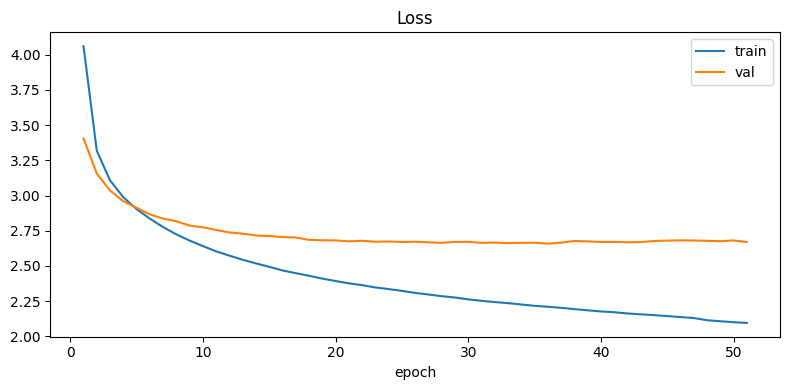

Saved plot → ./outputs/loss_curve_b.png


In [ ]:
epochs_range = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, train_losses, label="train")
ax.plot(epochs_range, val_losses, label="val")
ax.set_title("Loss")
ax.set_xlabel("epoch")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=120)
plt.show()